In [2]:
import numpy as np
import matplotlib.pyplot as plt

import networkx as nx
import math
%matplotlib inline

To visualize a convolutional neural network(CNN), we will draw a graph in code. The main idea here is that not every node is connected.     
    

CNN is locally connected, not densely connected.

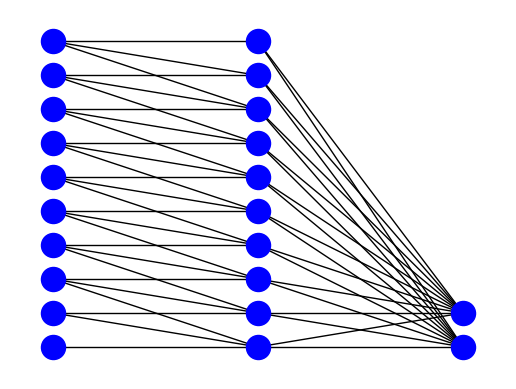

In [3]:
convolve = nx.Graph()
inputs = {i: (0,i) for i in range(0,10)}
activations = {i+100: (1,i) for i in range(0,10)}
outputs = {i+1000: (2,i) for i in range(0,2)}
all = {**inputs,**activations,**outputs}

## And now, -- convolutionally connected 

def window(items,kernel):
    windows = []
    at = 0
    while at < len(items)+kernel:
        windows.append(items[at:at+kernel])
        at +=1
    return windows

for i,w in enumerate(window(list(inputs.keys()),3)):
    for input in w:
        convolve.add_edge(input,i+100)
for activation in activations:
    for output in outputs:
        convolve.add_edge(activation,output)
nx.draw_networkx_nodes(convolve,all,nodelist=all.keys(),node_color='b')
nx.draw_networkx_edges(convolve,all)
plt.axis('off')
pass

input layer is connected to activations as 1:3

and now in 2 dimensions, we will take a 3*3 patch and show how it is connected

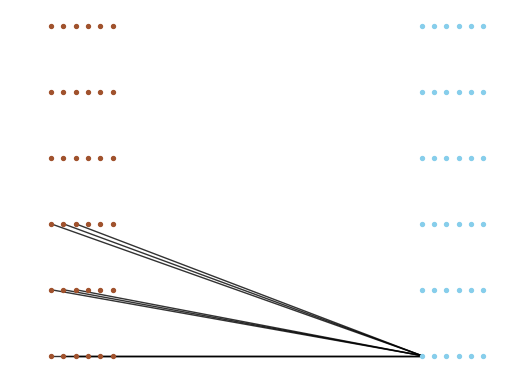

In [4]:
import itertools
import matplotlib.pyplot as plt
size = 6

mnist = nx.Graph()
pixels = {i: (x,y) for i,(x,y) in enumerate(itertools.product(range(0,size),range(0,size)))}
pixel_lookup = {position: i for i, position in pixels.items()}
activations = {i+1000: (x+30,y) for i,(x,y) in enumerate(itertools.product(range(0,size),range(0,size)))} 
all = {**pixels,**activations}
for x in range(0,3):
    for y in range(0,3):
        pixel = pixel_lookup[(x,y)]
        mnist.add_edge(pixel,1000)
nx.draw_networkx_nodes(mnist,pixels,nodelist=pixels.keys(),node_color='sienna',node_size=8)
nx.draw_networkx_nodes(mnist,activations,nodelist=activations.keys(),node_color='skyblue',node_size=8)
nx.draw_networkx_edges(mnist,all,alpha=0.8)
plt.axis('off')
pass

here, 3*3 grid is connected to one node

Convolutions efficiently encode regions of an image. It encodes adjacent pixels together, creating regions. Convolution is efficient due to the sparse number of connections compared to dense networks. 

and now, -- pooling. Pooling combines numerical values looking for the strongest/maximum signal. Demonstrating this - we will learn a new trick, using keras, just to do math. 

In [5]:
import keras
from keras.datasets import mnist
from keras.models import Sequential,Model
from keras.layers import Dense,Input,Dropout,Flatten, Conv2D, MaxPooling2D,MaxPooling1D
import numpy as np

In [6]:
sample = np.array([
    [1,1,4,1],
    [1,1,1,1],
    [2,1,1,5],
    [1,3,1,1],
])
pool = Sequential()
pool.add(MaxPooling1D(pool_size=(4),input_shape=(4,4)))
pooled = np.squeeze(pool.predict_on_batch(np.array([sample])))
print(pooled)
pass

/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/52-Packt-Tensorflow-Deep-Learning-Solutions-for-Images-Will-Ballard/.venv/lib/python3.12/site-packages/keras/src/layers/pooling/base_pooling.py:23: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(name=name, **kwargs)
2026-08-15 19:49:22.501908: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-08-15 19:49:22.502051: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-08-15 19:49:22.502059: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
I0000 00:00:1786803562.502521 1535085 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1786803562.502563 1535085 pluggable_device_factory.cc:271] Created 

[2. 3. 4. 5.]


Output here is maximum value from one dimension which column here. So, 2 is maximum in first column, 3 is maximum in 2nd column and so on.

np.squeeze eliminate the batch dimensions to get nice flatten output.

Pooling in 2 dimensions is set up a bit different. There is a 'Third dimension' -- the channel. Typically this is used for color images such as Red/Green/Blue pixel channels but we will limit our example to one channel of Black/White.    
   
Numpy expand_dims will tack on an additional 'dimension' with only one possible value in order to fit keras asssumptions. squeeze is opposite of expand_dims.

In [7]:
pool2 = Sequential()
pool2.add(MaxPooling2D(pool_size=(2),input_shape=(4,4,1)))
pooled2 = np.squeeze(pool2.predict_on_batch(np.array([np.expand_dims(sample,-1)])))
for row in pooled2:
    print(row)

[1. 4.]
[3. 5.]


/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/52-Packt-Tensorflow-Deep-Learning-Solutions-for-Images-Will-Ballard/.venv/lib/python3.12/site-packages/keras/src/layers/pooling/base_pooling.py:23: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(name=name, **kwargs)


Here, output values contain the maximum of 2*2 sub regions like 1 is max(1,1,1,1) (left upper region) and 4 is max(4,1,1,1) (right upper region) 

Pooling extracts the strong signals. It reduces the size and strengthen the signal. Effectively, pooling helps identify the most important pixels and regions.

and now -- knowing about convolution and pooling, let's use these layers and do some machine learning. first -- MNIST digits.  

In [8]:
(x_train,y_train),(x_test,y_test)= mnist.load_data()
x_train = np.expand_dims(x_train/np.max(x_train),-1)
x_test = np.expand_dims(x_test/np.max(x_test),-1)
y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

And now, using Keras, build a model that has convolution, pooling, dropout and a final softmax classification.

One thing to note here is Flatten. Because our images are 2-dimensional (x,y) pairs and our output is 1-dimension -- a class 0-9, Flatten is needed to reduce the dimension.

In [9]:
input_shape = x_train[0].shape
num_classes = 10
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3),activation='relu', input_shape=input_shape))
model.add(Conv2D(64,(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes,activation='softmax'))
model.summary()

/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/52-Packt-Tensorflow-Deep-Learning-Solutions-for-Images-Will-Ballard/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

With the model assembled, we compile it, which prepares the model for execution with a solver. And fit to the training data. This is similar to what we did with the Classical/Dense network -- in fact identical.

In [10]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
history = model.fit(x_train,y_train,batch_size=64,epochs=8,verbose=1,validation_data=(x_test,y_test))

Epoch 1/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.9226 - loss: 0.2779 - val_accuracy: 0.9800 - val_loss: 0.0744
Epoch 2/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9623 - loss: 0.1809 - val_accuracy: 0.9810 - val_loss: 0.0983
Epoch 3/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9613 - loss: 0.2798 - val_accuracy: 0.9818 - val_loss: 0.1339
Epoch 4/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.9636 - loss: 0.3911 - val_accuracy: 0.9858 - val_loss: 0.1559
Epoch 5/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9657 - loss: 0.4560 - val_accuracy: 0.9841 - val_loss: 0.2296
Epoch 6/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9636 - loss: 0.7970 - val_accuracy: 0.9856 - val_loss: 0.3483
Epoch 7/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9653 - loss: 1.0845 - val_accuracy: 0.9828 - val_loss: 0.6078
Epoch 8/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9666 - loss: 1.4502 - val_accu

By adding convolution layer, we improved the accuracy as compared to previous.